# Tutorial 1 — Identification: from a causal graph to an estimand

**Identification** asks a symbolic question: given a causal graph with latent
confounders, *can* the interventional distribution `P(Y | do(X))` be written as a
formula in the observational distribution — and if so, *which* formula?

CausalPy answers this with a single call:

```python
identify.causal_identification(G, X, Y)
```

It returns the estimand, or `None` when the effect is **not identifiable**. This
notebook walks through seven cases of increasing difficulty — back-door, front-door,
the Napkin graph, a *nested* Napkin, a multi-treatment sequential (mSBD) effect, a
plan-identification effect, and a non-identifiable bow — and for each one shows the
**drawn graph**, the plain-text estimand, and the **rendered LaTeX formula**.

> Graphs are `networkx.DiGraph`s. Latent confounders are explicit nodes named
> `U...` (each `U` node points to the variables it confounds). Treatments are named
> `X...`, outcomes `Y...`, and everything else is an observed covariate.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

## Helpers

`causal_identification` prints its reasoning as it works, so we wrap it to keep only
the returned estimand — once for the plain-text form (`latex=False`) and once for the
LaTeX form (`latex=True, copyTF=False`). A small drawing helper renders the ADMG:
**orange = treatment, green = outcome, blue = observed covariate, gray dashed =
latent confounder**.

In [2]:
import io, contextlib
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Math
import example_SCM, identify


def graph_of(name):
    """Build the (preprocessed) graph, treatments and outcomes of an example SCM."""
    scm, X, Y = getattr(example_SCM, name)(seednum=42)
    return identify.preprocess_GXY_for_ID(scm.graph, X, Y)


def idq(G, X, Y):
    """Identification, quietly; returns the plain-text estimand (or None)."""
    with contextlib.redirect_stdout(io.StringIO()):
        return identify.causal_identification(G, X, Y, latex=False, copyTF=False)


def idq_latex(G, X, Y):
    """Identification, quietly; returns the LaTeX estimand (or None)."""
    with contextlib.redirect_stdout(io.StringIO()):
        return identify.causal_identification(G, X, Y, latex=True, copyTF=False)


def draw_admg(G, X, Y, title=""):
    """Draw the ADMG: treatments orange, outcomes green, covariates blue,
    latent U-nodes gray with dashed confounding arrows."""
    pos = nx.kamada_kawai_layout(G)
    latent = [n for n in G.nodes if n.startswith("U")]
    treat = [n for n in G.nodes if n in X]
    outc = [n for n in G.nodes if n in Y]
    other = [n for n in G.nodes if n not in latent + treat + outc]
    plt.figure(figsize=(5.4, 3.8))
    for nodes, fc, ec in [(other, "#bfdbfe", "#1e40af"), (treat, "#fed7aa", "#c2410c"),
                          (outc, "#bbf7d0", "#15803d"), (latent, "#e5e7eb", "#6b7280")]:
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=fc,
                               edgecolors=ec, node_size=1250)
    solid = [(a, b) for a, b in G.edges if not a.startswith("U")]
    dashed = [(a, b) for a, b in G.edges if a.startswith("U")]
    nx.draw_networkx_edges(G, pos, edgelist=solid, node_size=1250, arrowsize=15, width=1.4)
    nx.draw_networkx_edges(G, pos, edgelist=dashed, node_size=1250, arrowsize=13,
                           style="dashed", edge_color="#9ca3af")
    nx.draw_networkx_labels(G, pos, font_size=9)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1. Back-door

The simplest case: a single **observed** confounder `C` affects both the treatment
`X` and the outcome `Y`. Adjusting for `C` blocks the back-door path `X ← C → Y`,
giving the classic adjustment formula.

> Within a conditioning set the variables are listed in a fixed sorted order
> (e.g. always `P(Y | C, X)`), so the estimand string is reproducible across runs.

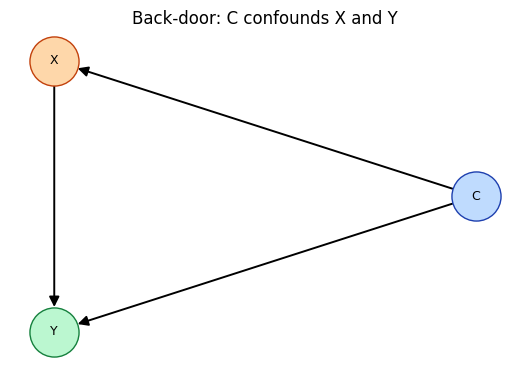

P(Y | do(X)) = Σ_{c}P(Y | C, X) P(C)


<IPython.core.display.Math object>

In [3]:
G, X, Y = graph_of("BD_SCM")
draw_admg(G, X, Y, title="Back-door: C confounds X and Y")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 2. Front-door

A **latent** confounder `U_XY` sits between `X` and `Y` and cannot be adjusted for —
but a mediator `Z` carries the whole effect (`X → Z → Y`) and is itself unconfounded
with `X`. The effect is identified *through* `Z` as a two-stage expression.

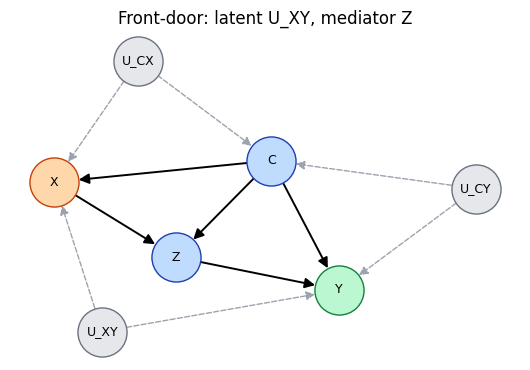

P(Y | do(X)) = Σ_{c, z} P(Z | C, X)P(C) Σ_{x} P(Y | C, X, Z)P(X | C)


<IPython.core.display.Math object>

In [4]:
G, X, Y = graph_of("Canonical_FD_SCM")
draw_admg(G, X, Y, title="Front-door: latent U_XY, mediator Z")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 3. The Napkin graph

Neither back-door nor front-door applies here, yet the effect is identifiable.
CausalPy derives it from Tian's **c-component factorization**, which yields a
**ratio** estimand: the `W`-marginalized joint over the `X`-containing c-component,
divided by its own normalization.

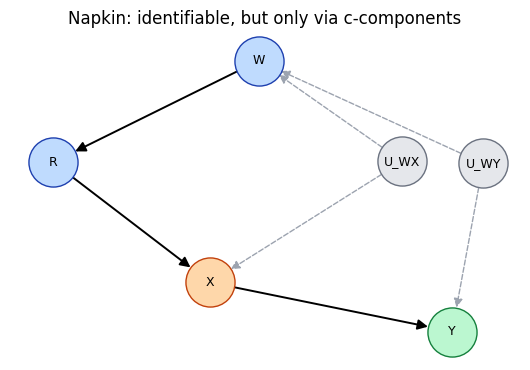

P({Y} | do({X})) = [[Σ_{w}P(X, Y | R, W) P(W)]/[Σ_{w}P(X | R, W) P(W)]]


<IPython.core.display.Math object>

In [5]:
G, X, Y = graph_of("Napkin_SCM")
draw_admg(G, X, Y, title="Napkin: identifiable, but only via c-components")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 4. A nested Napkin (harder)

The same idea two layers deep: a chain `V1 → … → V4 → X → Y` where **four latent
confounders** tie the chain to `X` and `Y`. The estimand is again a ratio, but now
the numerator and denominator each contain a *nested* marginalization over parts of
the chain (`v1, v3`).

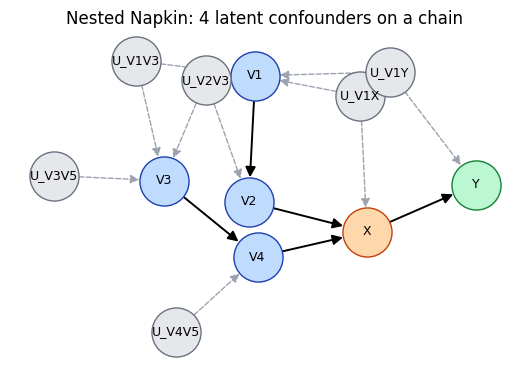

P({Y} | do({X})) = [[Σ_{v1, v3} P(X, Y | V1, V2, V3, V4) P(V3 | V1, V2) P(V1)]/[Σ_{v1, v3} P(X | V1, V2, V3, V4) P(V3 | V1, V2) P(V1)]]


<IPython.core.display.Math object>

In [6]:
G, X, Y = graph_of("Nested_Napkin_SCM")
draw_admg(G, X, Y, title="Nested Napkin: 4 latent confounders on a chain")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 5. Multi-treatment, multi-outcome (sequential back-door)

Identification is not limited to a single `X` and `Y`. Here a **time-ordered regime**
`X1, X2` acts on two outcomes `Y1, Y2` with interleaved covariates `Z1, Z2`. The
estimand is a *sequential* back-door factorization — each factor conditions only on
the past.

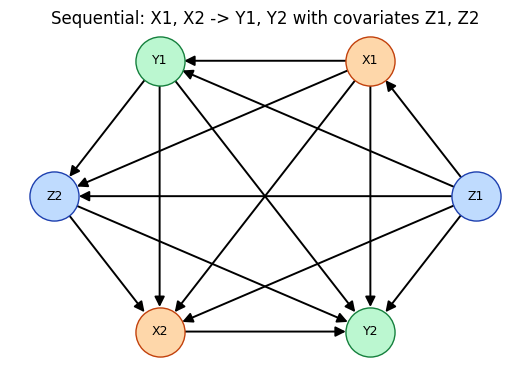

P(Y1, Y2 | do(X1, X2)) = Σ_{z1, z2} P(Y2 | X1, X2, Y1, Z1, Z2) P(Y1, Z2 | X1, Z1) P(Z1)


<IPython.core.display.Math object>

In [7]:
G, X, Y = graph_of("mSBD_SCM")
draw_admg(G, X, Y, title="Sequential: X1, X2 -> Y1, Y2 with covariates Z1, Z2")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 6. Plan identification

A two-step plan `do(X1, X2)` where the second treatment is confounded with the
outcome. The estimand combines a c-factor for `R` with a marginalized adjustment —
a form that no single back-door or front-door rule produces.

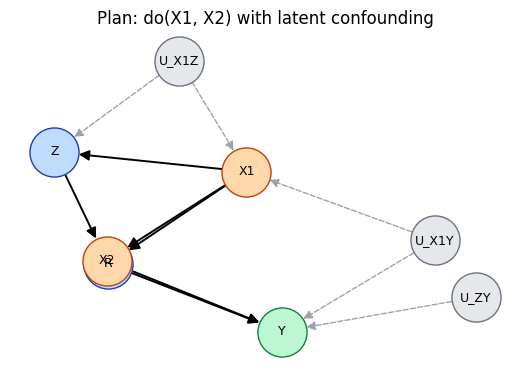

P({Y} | do({X1, X2})) = Σ_{r}[P(R | X1)]*[Σ_{x1, z}P(Y | R, X1, X2, Z) P(X1, Z)]


<IPython.core.display.Math object>

In [8]:
G, X, Y = graph_of("Plan_ID_SCM")
draw_admg(G, X, Y, title="Plan: do(X1, X2) with latent confounding")
print(idq(G, X, Y))
Math(idq_latex(G, X, Y))

## 7. When it is *not* identifiable

If a treatment and outcome are joined by **both** a direct edge `X → Y` *and* a
latent confounder `U_XY` (a "bow"), no formula in the observational distribution
equals `P(Y | do(X))`. Identification returns `None` — and, run unquietly, explains
why.

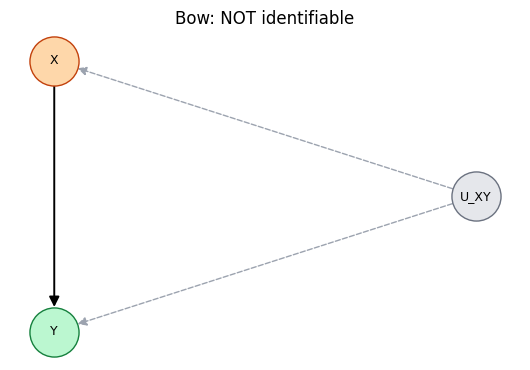

P(Y | do(X)) is not identifiable from G, since Q[['Y']] is not identifiable from G(['X', 'Y'])
returned: None


In [9]:
Gb = nx.DiGraph()
Gb.add_edges_from([("U_XY", "X"), ("U_XY", "Y"), ("X", "Y")])
Gb, Xb, Yb = identify.preprocess_GXY_for_ID(Gb, ["X"], ["Y"])
draw_admg(Gb, Xb, Yb, title="Bow: NOT identifiable")

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    result = identify.causal_identification(Gb, Xb, Yb, latex=False, copyTF=False)

print(buf.getvalue().strip())     # the function's own explanation
print("returned:", result)

A `None` return is CausalPy's verdict that the effect cannot be identified from
observational data alone.

`example_SCM.py` has more graphs to play with — `Double_Napkin_SCM`,
`Napkin_FD_SCM`, the `Bhattacharya2022_Fig*` benchmarks — all usable with exactly
the same three lines: `graph_of` → `draw_admg` → `causal_identification`.

---

**Next:** [Tutorial 2 — Estimation](02_estimation.ipynb) takes an identifiable effect
and estimates it from data, checking the answer against a known ground truth.